# Открытее Pool

In [44]:
import numpy as np
import matplotlib.pyplot as plt

Входные данные:
- Сумма на счете
- Цена при входе(открытии) ***pool***

- Ширина диапазона
- Процент асимметрии (Коэф. асимметрии)

In [ ]:
Capital = 100000
Price = 2000
Range = 1000
asymmetry_pct = 30

$Cap$ - Капитал *(сумма на счете)*  
$\sigma_{asyncUp}$ - Коэф. асимметрии, отступ сверху  
$range$ - Ширина ***Pool***

При открытии ***Pool*** фиксируем цену

$p_{in}= $ Цена при входе(открытии) ***pool***

Расчет порогов ***Pool***

$p_b$ - Верхний  
$p_n$ - Середина  
$p_a$ - Нижний  
$BEP$ - Величина без убыточности  

$p_n=p_{in}$

$p_b = p_n + range \cdot \sigma_{asyncUp}$

$p_a = p_n + range \cdot (1-\sigma_{asyncUp})$

$BEP=brentq(PnL(x, p_n, p_a, p_b, L),p_a \cdot 1.001, p_n \cdot 0.999)$

---



$PnL(x, ...) = S_{profit} - P_{loss}$  -> Рассчитывает общий PnL (шорт + пул) при заданной цене


$P_{loss} = P_{enter} - P_{current}$ -> Рассчитывает потерю пула от цены входа до текущей цены цене  
$p_{enter} = p_x(price_{in})$ -> входящий размер пула  
$p_{current} = p_x(price_{current})$ -> текущий  размер пула 

$P_{loss} = p_x(price_{in}) - p_x(price_{current})$ -> Рассчитывает потерю пула от цены входа до текущей цены цене  

---
Рассчитывает стоимость пула при заданной цене <small>_(ТОЛЬКО по формуле V3)_</small>


$$
p_x(price, p_a, p_b, l) = 
\begin{cases}                % Start of the cases environment
 0 & l \leq 0 \\
 l \cdot (\frac{1}{\sqrt{p_a}} - \frac{1}{\sqrt{p_b}}) \cdot price & price \leq p_a \\
 l \cdot (\sqrt{p_b}-\sqrt{p_a}) & price \geq p_b \\
 l \cdot (\sqrt{price}-\sqrt{p_a}) + (l \cdot (\frac{1}{\sqrt{price}}-\frac{1}{\sqrt{p_b}})) \cdot price & \text{иначе}
\end{cases}                  % End of the cases environment
$$,

----

$S_s$ - (short_size)  
$S_p$ - (short_profit)  

---

$L$ - Ликвидность

$$
L(Cap, p_n, p_a, p_b )= 
\begin{cases}
\frac{Cap}{t_1+t_2} & t_1 + t_2 \neq 0 \\
0 & otherwise \\
\end{cases}
$$
где
$$
t_1=\sqrt{p_n} - \sqrt{p_a} \\
t_2=(\sqrt{p_n} - \sqrt{p_a}) + p_n \cdot (\frac{1}{\sqrt{p_n}} - \frac{1}{\sqrt{p_b}}) \\
$$
где
$$
p_n=\begin{cases}
\frac{p_a + p_b}{2} & p_a \geq p_n \geq p_b \\
p_n & otherwise
\end{cases}
$$



```python
brentq(
    lambda p: calculate_total_pnl_at_price(p, pn, pa, pb, l),
    pa * 1.001,
    pn * 0.999,
    maxiter=100
)
```

```python
# --- ИСПРАВЛЕННАЯ ФОРМУЛА ликвидности для Uniswap V3 ---
def calculate_liquidity(capital_amount, pn_price, pa_price, pb_price):
    """Правильная формула ликвидности для Uniswap V3"""
    if pn_price <= pa_price or pn_price >= pb_price:
        pn_price = (pa_price + pb_price) / 2
    sqrt_pn = np.sqrt(pn_price)
    sqrt_pa = np.sqrt(pa_price)
    sqrt_pb = np.sqrt(pb_price)
    
    term1 = sqrt_pn - sqrt_pa
    term2 = pn_price * (1/sqrt_pn - 1/sqrt_pb)
    if (term1 + term2) == 0:
        return 0.0
    
    l = capital_amount / (term1 + term2)
    
    if verbose_logging and abs(calculate_pool_value(pn_price, pa_price, pb_price, l) - capital_amount) > capital_amount * 0.01:
        print(f"  Внимание: разница в расчетах. Capital=${capital_amount:.2f}, Pool Value at Pn=${calculate_pool_value(pn_price, pa_price, pb_price, l):.2f}")
    return l
```

In [46]:
p_n = 2000
Range = 1000
Asyn_pct = 50
Kasyn = 0.3

p_b_1 = p_n + Range * Asyn_pct/100
p_b_2 = p_n + Range * Kasyn

p_a_1 = p_n - Range * (100-Asyn_pct)/100
p_a_2 = p_n - Range * (1-Kasyn)

out_b = p_b_1 == p_b_2
out_a = p_a_1 == p_a_2

# --------------------------------------

print(out_b, out_a)
print("Up",p_b_1, p_b_2)
print("Down",p_a_1, p_a_2)

False False
Up 2500.0 2300.0
Down 1500.0 1300.0


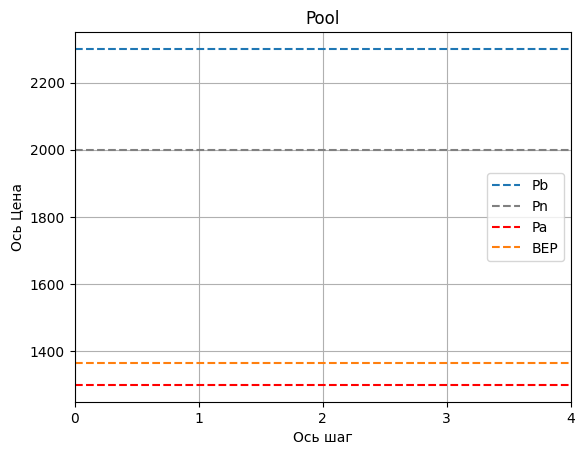

In [47]:
pb = p_b_2
pn = p_n
pa = p_a_2
bep = 1365
# prices = np.array([2000,2020,1950,1400,1450])

step_count = 5 #len(prices)
steps = np.arange(step_count,dtype=np.int16)

plt.axhline(y=pb,linestyle='--',label='Pb')
plt.axhline(y=pn,linestyle='--',color='gray',label='Pn')
plt.axhline(y=pa,linestyle='--',color='red',label='Pa')
plt.axhline(y=bep,linestyle='--',color='tab:orange',label='BEP')

# plt.scatter(steps,prices)
# plt.plot(steps,prices,color='blue',label='Цена')

# plt.axvline(x=0, color='g', linestyle='--', label='Открыть пул')
# plt.axvline(x=3, color='r', linestyle='--', label='Закрыть пул')

plt.xticks(steps)

plt.title('Pool')
plt.xlabel('Ось шаг')
plt.ylabel('Ось Цена')
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [48]:
import numpy as np
import matplotlib.pyplot as plt #[2](https://www.mycompiler.io/view/5fKm4ccoy2Q)

from scipy.optimize import brentq

# Определить функцию уравнения
def equation(x):
    print(x)
    return x #x**3 - 2*x - 5

# Найти корень уравнения в интервале [-10, 10]
root = brentq(equation, 
              pa * 1.001,
              pn * 0.999,
              maxiter=100
              )

# Построить корень и значение функции в нём
plt.plot(root, equation(root), 'rx', label='Root')
plt.text(root, equation(root), f'({root:.4f}, {equation(root):.4f})', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

1301.3
1998.0


ValueError: f(a) and f(b) must have different signs

In [51]:
a = 1.5
print(1<=a<=2)

True
